In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from data_prep.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

load_dotenv(override=True)

True

In [2]:
groq_api_key = os.getenv("GROQ_API_KEY")
if groq_api_key:
    print("GROQ_API_KEY is set.")
else:
    print("GROQ_API_KEY is not set.")

openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
if openrouter_api_key:
    print("OPENROUTER_API_KEY is set.")
else:
    print("OPENROUTER_API_KEY is not set.")

hf_token = os.environ['HF_TOKEN']
if hf_token:
    print("HuggingFace token found.")
else:
    print("No HuggingFace token found.")

login(hf_token, add_to_git_credential=True)

#------------------------------

openrouter_url = "https://openrouter.ai/api/v1"



Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


GROQ_API_KEY is set.
OPENROUTER_API_KEY is set.
HuggingFace token found.


In [3]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

In [4]:
username = "leearum95"
dataset = f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test




  0%|          | 0/27099 [00:00<?, ?it/s]

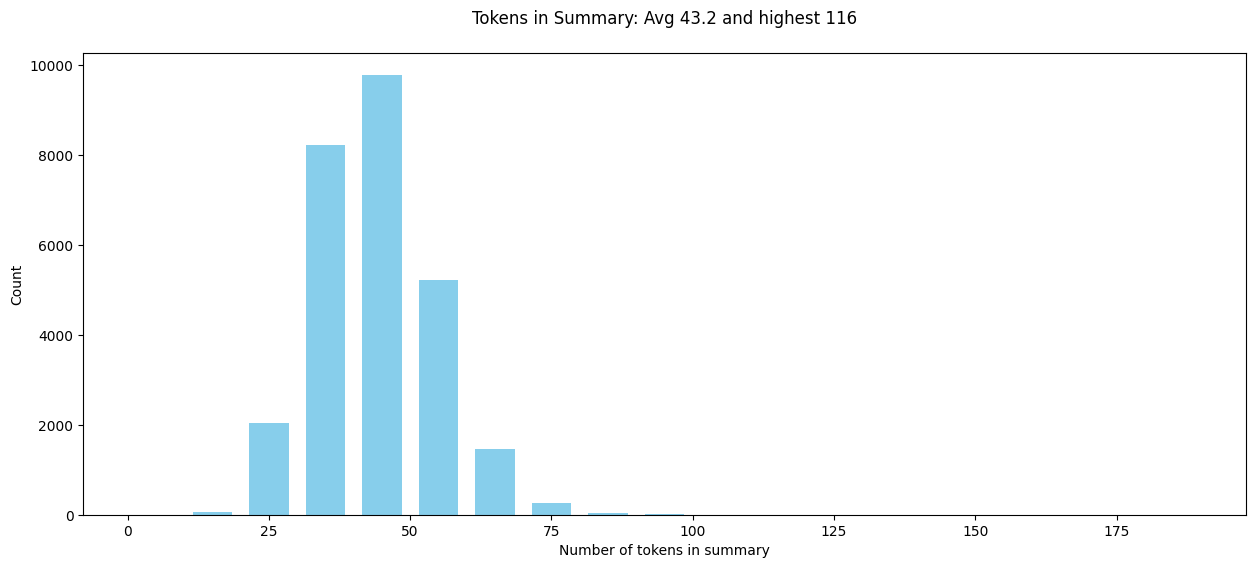

In [5]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]
plt.figure(figsize=(15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

In [6]:
CUTOFF = 75
for item in tqdm(train+val):
    item.make_prompts(tokenizer, CUTOFF)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF)


  0%|          | 0/24000 [00:00<?, ?it/s]

  0%|          | 0/3099 [00:00<?, ?it/s]

In [7]:
print("PROMPT:")
print(test[0].prompt)
print("COMPLETION:")
print(test[0].completion)

PROMPT:
What is the category of the following product judging by its title and description?

The Akai Professional APC64 is an advanced Ableton Live MIDI controller with 64 RGB velocity-sensitive pads, touch strips, internal step sequencer, real-time visual feedback, and comprehensive hardware control, designed for music production, live performance, and creative experimentation.

The category is
COMPLETION:
Arts & Entertainment


  0%|          | 0/20000 [00:00<?, ?it/s]

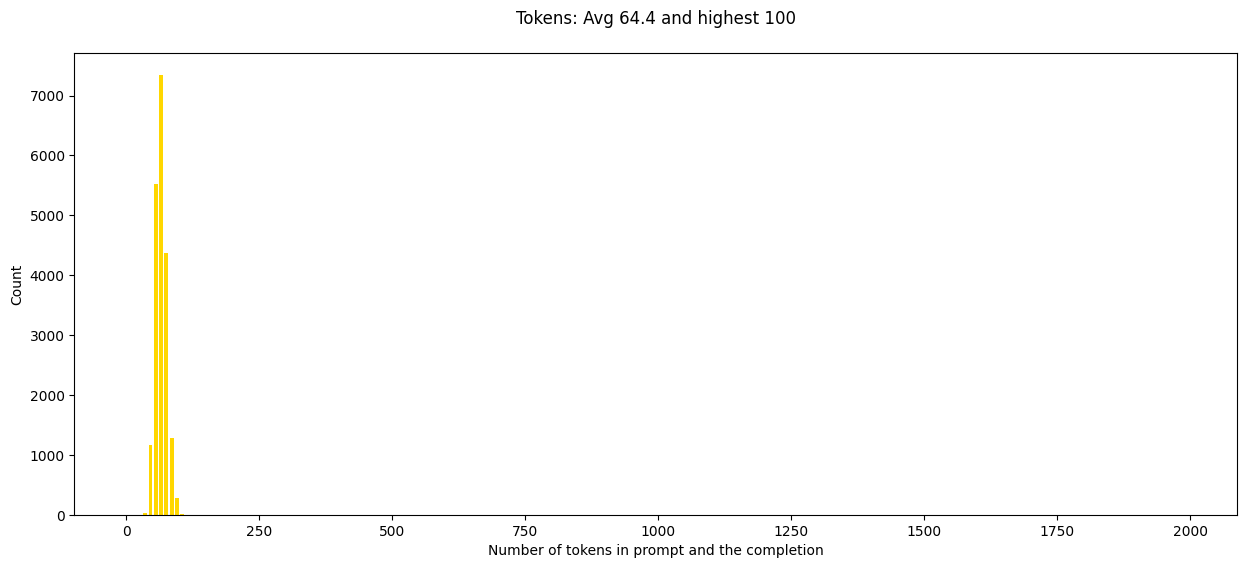

In [8]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(train)]
plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 2000, 10))
plt.show()

In [9]:
username = "leearum95"
dataset = f"{username}/items_prompts_full_no_category"

Item.push_prompts_to_hub(dataset, train, val, test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            